In [25]:
%reload_ext autoreload
%autoreload 2

In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from losses import supervised_loss, add_sup_losses, matched_radius_consistency_loss, matched_reprojection_loss_2d, match_vision_to_target_cylinders

from debugger import bug_check


In [27]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 5050 Laptop GPU


In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=8,
    in_chans=3,
    embed_dim=384,
    depth=6,
    num_heads=6,
    num_bins=128,
    dropout=0.1,
).to(device)


In [29]:
dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    debug=False,
    return_two_pairs=True
)

loader = DataLoader(
    dataset,
    batch_size=12,
    shuffle=True,
    num_workers=0,
)

In [30]:
# bug_check(0)

import torch.nn.functional as F


if False:
    debug_dataset = SceneTwoPairsDataset(
        root_dir="dataset",
        return_two_pairs=False
    )

    debug_loader = DataLoader(
        debug_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0,
    )


    batch = next(iter(debug_loader))
    img_a, vision_a, img_b, vision_b, pose_ab = batch


In [31]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Hyperparameters
LAMBDA_OCC = 10.0
LAMBDA_RADIUS = 10.0
OCC_THRESH= 0.5

LAMBDA_REPROJ = 2.0
LAMBDA_CONS = 2.0

history = {
    "total": [],
    "supervised": [],
    "vision": [],
    "pose": [],
    "radius_consistency": [],
    "reprojection": [],
}

model.train()
for epoch in range(500):
    total = 0.0
    total_vis1 = 0.0
    total_radius1 = 0.0
    total_depth1 = 0.0
    total_pose1 = 0.0
    total_t1 = 0.0
    total_r1 = 0.0

    total_vis2 = 0.0
    total_radius2 = 0.0
    total_depth2 = 0.0
    total_pose2 = 0.0
    total_t2 = 0.0
    total_r2 = 0.0

    total_radius_cons_loss = 0.0
    total_reproj_loss = 0.0

    for batch in loader:
        # img_a1, vision_a1, img_b1, pose_ab1 = batch
        img_a1, vision_a1, img_b1, vision_b1, pose_ab1, img_a2, vision_a2, img_b2, vision_b2, pose_ab2 = batch

        img_a1 = img_a1.to(device, non_blocking=True)
        img_b1 = img_b1.to(device, non_blocking=True)
        vision_a1 = vision_a1.to(device, non_blocking=True)
        vision_b1 = vision_b1.to(device, non_blocking=True)
        pose_ab1 = pose_ab1.to(device, non_blocking=True)
        img_a2 = img_a2.to(device, non_blocking=True)
        img_b2 = img_b2.to(device, non_blocking=True)
        vision_a2 = vision_a2.to(device, non_blocking=True)
        vision_b2 = vision_b2.to(device, non_blocking=True)
        pose_ab2 = pose_ab2.to(device, non_blocking=True)

        pred_vision_a1, pred_vision_b1, pred_pose1 = model(img_a1, img_b1)
        pred_vision_a2, pred_vision_b2, pred_pose2 = model(img_a2, img_b2)

        loss_out1 = supervised_loss(pred_vision_a1, vision_a1, pred_vision_b1, vision_b1, pred_pose1, pose_ab1,
                                    occ_thresh=OCC_THRESH,
                                    lambda_occ=LAMBDA_OCC,
                                    lambda_radius=LAMBDA_RADIUS,
        )

        loss_out2 = supervised_loss(pred_vision_a2, vision_a2, pred_vision_b2, vision_b2, pred_pose2, pose_ab2,
                                    occ_thresh=OCC_THRESH,
                                    lambda_occ=LAMBDA_OCC,
                                    lambda_radius=LAMBDA_RADIUS,
        )

        radius_cons1 = matched_radius_consistency_loss(pred_vision_a1, vision_a1, pred_vision_b1, vision_b1,
            occ_thresh=OCC_THRESH,
        )
        radius_cons2 = matched_radius_consistency_loss(pred_vision_a2, vision_a2, pred_vision_b2, vision_b2,
            occ_thresh=OCC_THRESH,
        )

        reproj1 = matched_reprojection_loss_2d(pred_vision_a1, vision_a1, pred_vision_b1, vision_b1, pred_pose1,
            occ_thresh=OCC_THRESH,
            fov_degrees=90.0,
        )

        reproj2 = matched_reprojection_loss_2d(pred_vision_a2, vision_a2, pred_vision_b2, vision_b2, pred_pose2,
            occ_thresh=OCC_THRESH,
            fov_degrees=90.0,
        )

        sup_loss = (loss_out1["total"] + loss_out2["total"]) / 2.0
        reproj = (reproj1 + reproj2) / 2.0
        radius_cons = (radius_cons1 + radius_cons2) / 2.0

        loss = sup_loss + LAMBDA_REPROJ * reproj + LAMBDA_CONS * radius_cons

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total += loss.item()

        total_vis1, total_radius1, total_pose1, total_depth1, total_t1, total_r1 = add_sup_losses(
            total_vis1, total_radius1, total_pose1, total_depth1, total_t1, total_r1, loss_out1
        )
        total_vis2, total_radius2, total_pose2, total_depth2, total_t2, total_r2 = add_sup_losses(
            total_vis2, total_radius2, total_pose2, total_depth2, total_t2, total_r2, loss_out2
        )

        total_radius_cons_loss += radius_cons.item()

        total_reproj_loss += reproj.item()
        

    n = len(loader)

    epoch_total = total / n
    epoch_vision = (total_vis1 + total_vis2) / (2.0 * n)
    epoch_pose = (total_pose1 + total_pose2) / (2.0 * n)
    epoch_supervised = epoch_vision + epoch_pose
    epoch_radius_cons = total_radius_cons_loss / n
    epoch_reproj = total_reproj_loss / n

    history["total"].append(epoch_total)
    history["supervised"].append(epoch_supervised)
    history["vision"].append(epoch_vision)
    history["pose"].append(epoch_pose)
    history["radius_consistency"].append(epoch_radius_cons)
    history["reprojection"].append(epoch_reproj)

    print(
        f"Epoch {epoch+1}: "
        f"tot={total/n:.4f} | "
        f"vis={total_vis1/n:.4f} | "
        #f"r={total_radius1/n:.4f} | "
        #f"d={total_depth1/n:.4f} | "
        #f"pose={total_pose1/n:.4f} | "
        #f"t={total_t1/n:.4f} | "
        #f"r={total_r1/n:.4f} | "
        f"radius_cons={total_radius_cons_loss/n:.4f} | "
        f"reproj={total_reproj_loss/n:.4f}"
    )


Epoch 1: tot=23.1180 | vis=21.7011 | radius_cons=0.0396 | reproj=0.1490
Epoch 2: tot=21.0638 | vis=20.8063 | radius_cons=0.0210 | reproj=0.0148
Epoch 3: tot=20.2487 | vis=20.1395 | radius_cons=0.0277 | reproj=0.0103
Epoch 4: tot=19.4666 | vis=19.0903 | radius_cons=0.0658 | reproj=0.0231
Epoch 5: tot=19.4309 | vis=19.2637 | radius_cons=0.0080 | reproj=0.0016
Epoch 6: tot=18.6949 | vis=18.5635 | radius_cons=0.0000 | reproj=0.0000
Epoch 7: tot=18.3173 | vis=17.9925 | radius_cons=0.0000 | reproj=0.0000
Epoch 8: tot=18.0585 | vis=17.7435 | radius_cons=0.0000 | reproj=0.0000
Epoch 9: tot=17.6397 | vis=17.5743 | radius_cons=0.0000 | reproj=0.0000
Epoch 10: tot=16.9566 | vis=16.5811 | radius_cons=0.0000 | reproj=0.0000
Epoch 11: tot=16.5474 | vis=16.6881 | radius_cons=0.0000 | reproj=0.0000
Epoch 12: tot=16.4409 | vis=16.1766 | radius_cons=0.0000 | reproj=0.0000
Epoch 13: tot=15.6275 | vis=15.6577 | radius_cons=0.0000 | reproj=0.0000
Epoch 14: tot=15.6291 | vis=15.3498 | radius_cons=0.0000 | r

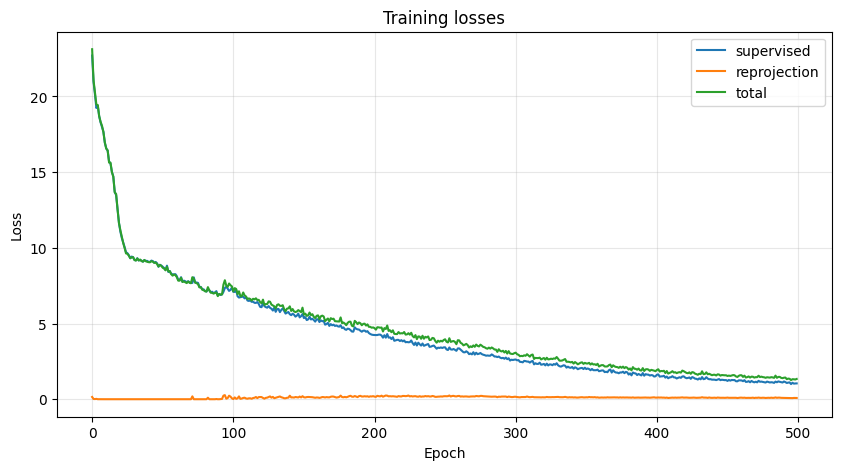

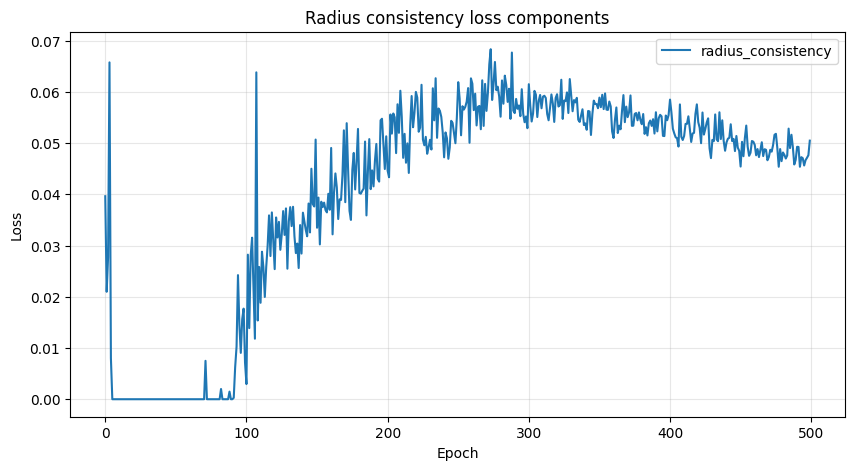

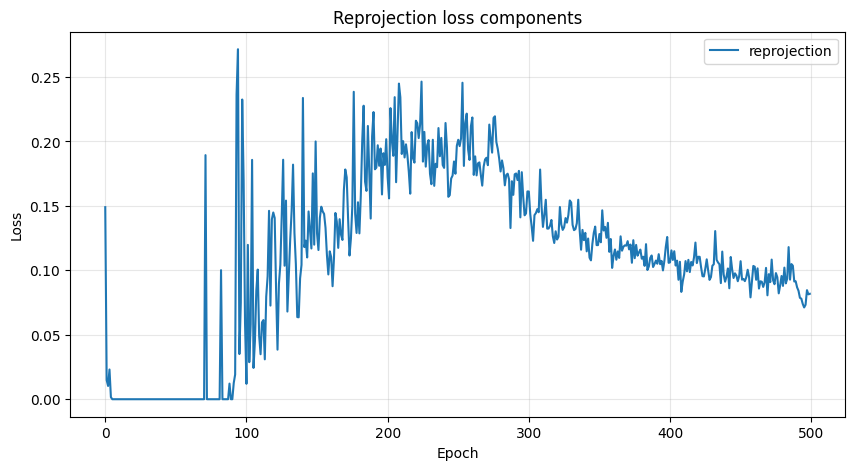

In [32]:
# Plot efter träning
plt.figure(figsize=(10, 5))
plt.plot(history["supervised"], label="supervised")
plt.plot(history["reprojection"], label="reprojection")
plt.plot(history["total"], label="total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["radius_consistency"], label="radius_consistency")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Radius consistency loss components")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["reprojection"], label="reprojection")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reprojection loss components")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
# Inference + utskrift + plottar på samma dataset som träningen
from utils import pose_to_text, show_image_pair

infer_dataset = SceneTwoPairsDataset(
    root_dir="testdataset",
    return_two_pairs=False
)

infer_loader = DataLoader(
    infer_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
)
model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, vision_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
vision_b = vision_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, _, pred_pose = model(img_a, img_b)

if False:
    # Skriv ut resultat för några samples
    n_show = min(4, img_a.shape[0])
    for i in range(n_show):
        print(f"Sample {i}")
        print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
        print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

        pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
        print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
        print()

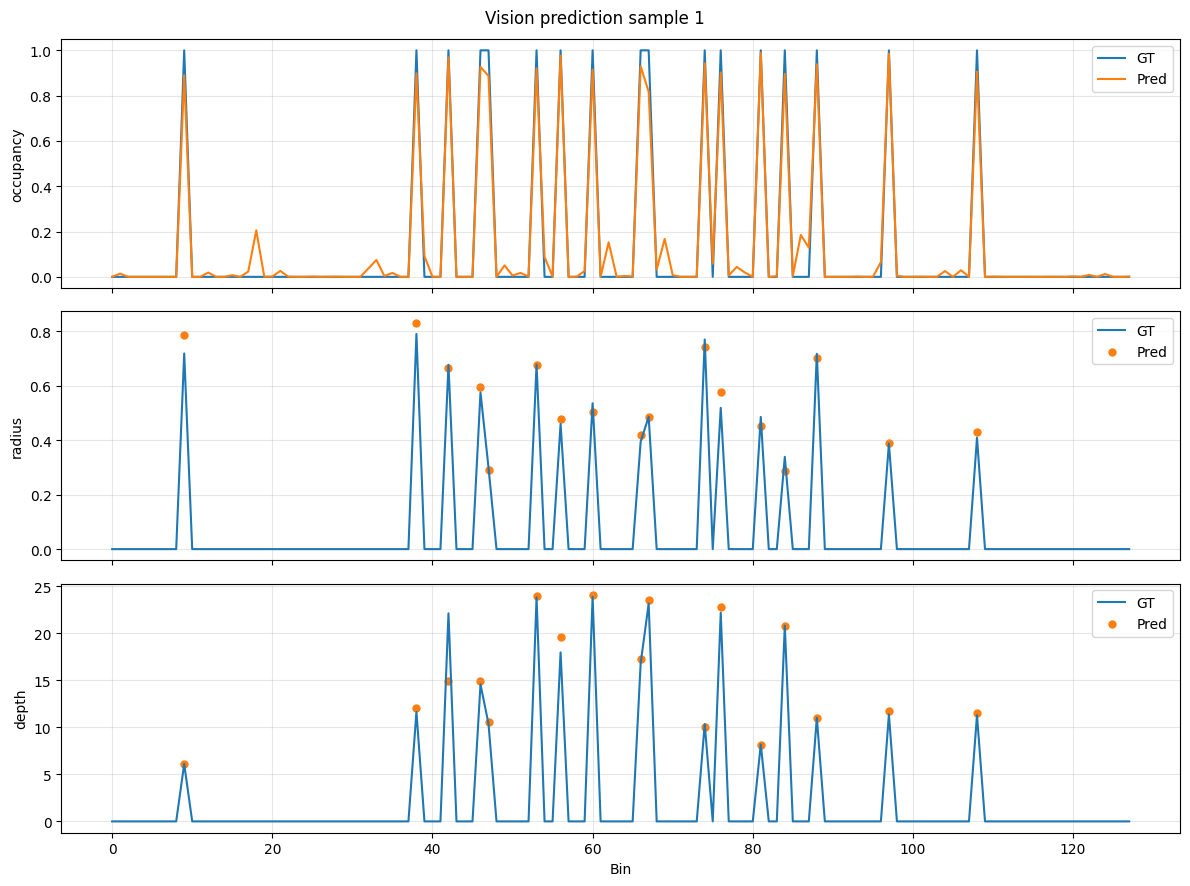

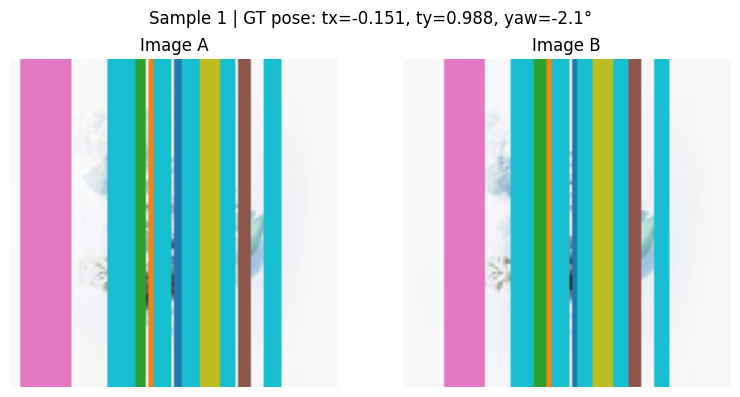

In [34]:
# Plotta vision-output för första samplet
sample_idx = 1
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
occ_threshold = 0.4

gt_occ = vision_a[sample_idx, :, 0].detach().cpu().numpy()
pr_occ = pred_vision[sample_idx, :, 0].detach().cpu().numpy()

for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    # GT alltid blå linje
    ax.plot(bins, gt, label="GT", color="tab:blue")

    if j == 0:
        # occupancy: pred som orange linje
        ax.plot(bins, pr, label="Pred", color="tab:orange")
    else:
        pr_mask = pr_occ > occ_threshold

        # pred som orange punkter
        ax.scatter(
            bins[pr_mask],
            pr[pr_mask],
            label="Pred",
            color="tab:orange",
            s=25
        )

    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()

# Plotta bildpar
show_image_pair(
    img_a[sample_idx].detach().cpu(),
    img_b[sample_idx].detach().cpu(),
    title=f"Sample {sample_idx} | GT pose: {pose_to_text(pose_ab[sample_idx].detach().cpu())}"
)

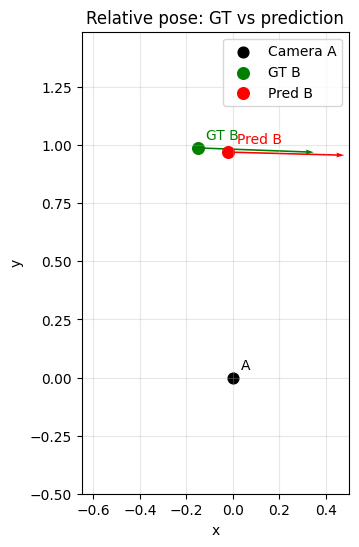

pred_vision shape: torch.Size([4, 128, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([-0.1514,  0.9885, -0.0373,  0.9993])
Pred pose: tensor([-0.0201,  0.9703, -0.0269,  0.9996])


In [35]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from utils import plot_relative_pose


# Visa första paret i batchen
if False:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img_a[sample_idx].cpu().permute(1, 2, 0))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b[sample_idx].cpu().permute(1, 2, 0))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Visa relative pose
plot_relative_pose(pose_ab[sample_idx], pred_pose[sample_idx])

print("pred_vision shape:", pred_vision.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[sample_idx].detach().cpu())
print("Pred pose:", pred_pose[sample_idx].detach().cpu())